In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [4]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


*   AT--Temperature (Ambient Temperature)
*   V--vacuum
*   AP--Pressure (Ambient Pressure)
*   RH--Humidity (Relative Humidity)
*   PE(Y-Axis)--Produced energy (Net hourly electrical energy output)

In [5]:
X = df.drop(columns="PE")
y = df["PE"]

In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [9]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

print(f"Shape of X_train_tensor: {X_train_tensor.shape}")
print(f"Shape of y_train_tensor: {y_train_tensor.shape}")
print(f"Shape of X_test_tensor: {X_test_tensor.shape}")
print(f"Shape of y_test_tensor: {y_test_tensor.shape}")

Shape of X_train_tensor: torch.Size([7654, 4])
Shape of y_train_tensor: torch.Size([7654, 1])
Shape of X_test_tensor: torch.Size([1914, 4])
Shape of y_test_tensor: torch.Size([1914, 1])


In [10]:
from torch.utils.data import TensorDataset, DataLoader

#Zipping X and y values
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [11]:
#Dividing samples into batches (1 Batch = 32 sample)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [12]:
X_train.shape[1]

4

**DEEP LEARNING**

In [13]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()

  #Layers
    self.model = nn.Sequential(
      # 1st hidden layer
      nn.Linear(X_train.shape[1], 6),#input features,output
      nn.ReLU(),

      # 2nd hidded layer
      nn.Linear(6, 6),
      nn.ReLU(),

      #output layer
      nn.Linear(6,1),
  )

  def forward(self, x):
    return self.model(x)


In [14]:
import torch.optim as optim
model = ANN()

#loos, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [15]:
#Train the ANN
train_losses = []
val_losses = []

min_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
  model.train()
  loss_per_batch = 0.0 #total training loss for 1 epoch

  for xb, yb in train_loader:
    # xb = features of 1 batch
    # yb = labels of 1 batch

    optimizer.zero_grad() #reset gradient to 0
    outputs = model(xb) # forward prop....predicted outputs
    loss = criterion(outputs, yb) # compute loss
    loss.backward() # back prop.. compute gradients
    optimizer.step() # parameter update

    loss_per_batch += loss.item() # loss is a tensor converting to pythn float

  epoch_train_loss = loss_per_batch / len(train_loader)
  train_losses.append(epoch_train_loss)

  #validation
  model.eval()
  loss_per_batch = 0.0

  with torch.no_grad(): # no gradients compute
    for xb, yb in test_loader:
      outputs = model(xb)
      loss = criterion(outputs, yb)
      loss_per_batch += loss.item()

  epoch_val_loss = loss_per_batch / len(test_loader)
  val_losses.append(epoch_val_loss)

  # ERROR ON TRAINING DATA AND TESTING DATA(VALIDATION LOSS)
  print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

  if epoch_val_loss < min_val_loss:
    min_val_loss = epoch_val_loss
    # Storing wieght and bias value in the .pt file
    torch.save(model.state_dict(),"Best_model.pt") # .pt or .pth file extension


epoch 1/100 ==> train loss = 206266.27174479168 & val loss = 204710.90546875
epoch 2/100 ==> train loss = 198356.58151041667 & val loss = 187330.78020833334
epoch 3/100 ==> train loss = 167579.1923828125 & val loss = 144500.61341145833
epoch 4/100 ==> train loss = 119327.52001953125 & val loss = 96571.49778645833
epoch 5/100 ==> train loss = 79269.33893229166 & val loss = 66407.15123697916
epoch 6/100 ==> train loss = 56444.54990234375 & val loss = 48519.773697916666
epoch 7/100 ==> train loss = 40413.74932454427 & val loss = 33552.3150390625
epoch 8/100 ==> train loss = 26966.072880045573 & val loss = 21407.09736328125
epoch 9/100 ==> train loss = 16637.226295979817 & val loss = 12812.684537760417
epoch 10/100 ==> train loss = 9862.737892659505 & val loss = 7597.172176106771
epoch 11/100 ==> train loss = 6004.858639526367 & val loss = 4873.835632324219
epoch 12/100 ==> train loss = 4109.969364420573 & val loss = 3520.946805826823
epoch 13/100 ==> train loss = 3018.4799204508463 & val 

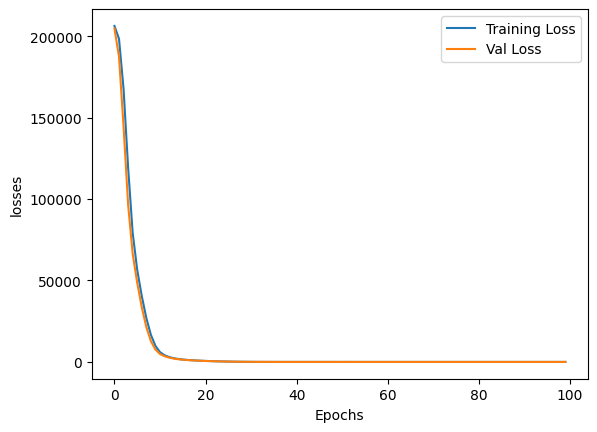

In [16]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss" )
plt.plot(loss_df["Validation Loss"], label = "Val Loss" )

plt.xlabel("Epochs")
plt.ylabel("losses")

plt.legend()

In [17]:
model.load_state_dict(torch.load("Best_model.pt"))

<All keys matched successfully>

In [18]:
# Evaluating the model

model.eval()
with torch.no_grad():
  train_pred = model(X_train_tensor)
  test_pred = model(X_test_tensor)

  train_mse_loss = criterion(train_pred, y_train_tensor)
  test_mse_loss = criterion(test_pred, y_test_tensor)

  print("Training MSE : ", train_mse_loss.item())
  print("Testing MSE : ", test_mse_loss.item())

Training MSE :  21.17710304260254
Testing MSE :  19.61499786376953


In [19]:
from sklearn.metrics import r2_score

print("R2 value : ", r2_score(y_test, test_pred))

R2 value :  0.9314506457255929


In [20]:
predicted_df = pd.DataFrame({
    "Predicted Values": test_pred.numpy().flatten(),
    "Actual Values": y_test.values
})
predicted_df

,Predicted Values,Actual Values
0,435.737793,433.27
1,437.313354,438.16
2,461.304077,458.42
3,475.944763,480.82
4,435.921753,441.41
...,...,...
1909,451.388550,456.70
1910,432.133484,438.04
1911,467.478394,467.80
1912,431.598877,437.14
